In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/titanic/train.csv
/kaggle/input/competitions/titanic/test.csv
/kaggle/input/competitions/titanic/gender_submission.csv
/kaggle/input/datasets/lespin/house-prices-dataset/sample_submission.csv
/kaggle/input/datasets/lespin/house-prices-dataset/data_description.txt
/kaggle/input/datasets/lespin/house-prices-dataset/train.csv
/kaggle/input/datasets/lespin/house-prices-dataset/test.csv


**Random Imputation**- Replace with random variable which is most frequent in given value.

In [2]:
import numpy as pandas
import pandas as pd
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv', usecols = ['Age','Fare','Survived'])

In [4]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [5]:
df.isnull().mean()*100

Survived     0.00000
Age         19.86532
Fare         0.00000
dtype: float64

In [6]:
x = df.drop(columns = ['Survived'])
y = df['Survived']

In [7]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 2)

In [8]:
x_train['Age_imputed'] = x_train['Age']
x_test['Age_imputed'] = x_test['Age']

In [9]:
x_train.head()

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0


In [10]:
x_test.head()

,Age,Fare,Age_imputed
707,42.0,26.2875,42.0
37,21.0,8.0500,21.0
615,24.0,65.0000,24.0
169,28.0,56.4958,28.0
68,17.0,7.9250,17.0


In [11]:
x_train.loc[x_train['Age_imputed'].isnull(), 'Age_imputed'] = \
    x_train['Age'].dropna().sample(x_train['Age_imputed'].isnull().sum()).values

x_test.loc[x_test['Age_imputed'].isnull(), 'Age_imputed'] = \
    x_test['Age'].dropna().sample(x_test['Age_imputed'].isnull().sum()).values

In [12]:
x_train

,Age,Fare,Age_imputed
30,40.0,27.7208,40.0
10,4.0,16.7000,4.0
873,47.0,9.0000,47.0
182,9.0,31.3875,9.0
876,20.0,9.8458,20.0
...,...,...,...
534,30.0,8.6625,30.0
584,NaN,8.7125,47.0
493,71.0,49.5042,71.0
527,NaN,221.7792,29.0


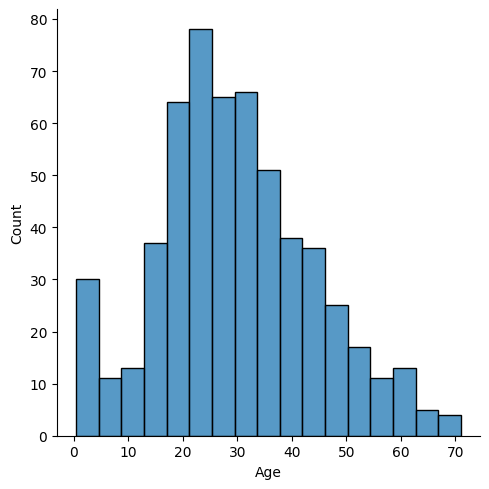

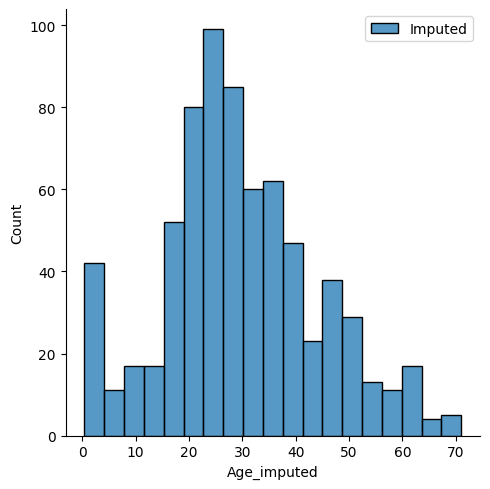

In [13]:
sns.displot(x_train['Age'],label = 'Original')
sns.displot(x_train['Age_imputed'],label = 'Imputed')
plt.legend()
plt.show()

In [14]:
print("Original variable varience :",x_train['Age'].var())
print("Varience after random imputation :",x_train['Age_imputed'].var())

Original variable varience : 204.3495133904614
Varience after random imputation : 208.16137722447388


In [15]:
x_train[['Fare','Age','Age_imputed']].cov()

,Fare,Age,Age_imputed
Fare,2368.246832,71.512440,57.860657
Age,71.512440,204.349513,204.349513
Age_imputed,57.860657,204.349513,208.161377


<Axes: >

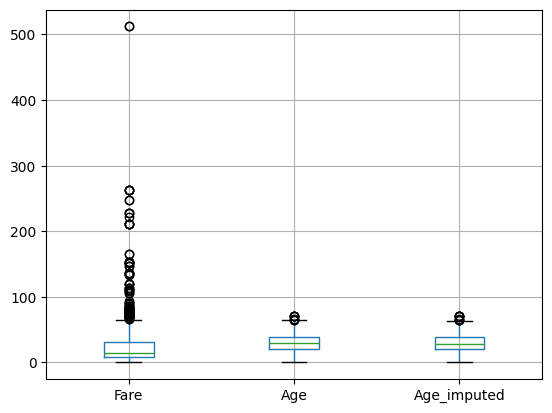

In [16]:
x_train[['Fare','Age','Age_imputed']].boxplot()

In [17]:
observation = x_train.iloc[0]

In [18]:
sampled_value = x_train['Age'].dropna().sample(1,random_state = int(observation['Fare']))

In [19]:
data = pd.read_csv('/kaggle/input/datasets/lespin/house-prices-dataset/train.csv',usecols = ['GarageQual','FireplaceQu','SalePrice'])

In [20]:
data.head()

,FireplaceQu,GarageQual,SalePrice
0,NaN,TA,208500
1,TA,TA,181500
2,TA,TA,223500
3,Gd,TA,140000
4,TA,TA,250000


In [21]:
data.isnull().mean()*100

FireplaceQu    47.260274
GarageQual      5.547945
SalePrice       0.000000
dtype: float64

In [22]:
x = data
y = data['SalePrice']

In [23]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 2)

In [24]:
x_train['GarageQual_imputed'] = x_train['GarageQual']
x_test['GarageQual_imputed'] = x_test['GarageQual']
x_train['FireplaceQu_imputed'] = x_train['FireplaceQu']
x_test['FireplaceQu_imputed'] = x_test['FireplaceQu']

In [25]:
x_train.sample(5)

,FireplaceQu,GarageQual,SalePrice,GarageQual_imputed,FireplaceQu_imputed
112,Gd,TA,383970,TA,Gd
1322,TA,TA,190000,TA,TA
630,NaN,Fa,124000,Fa,NaN
320,NaN,TA,342643,TA,NaN
1009,NaN,NaN,102000,NaN,NaN


In [26]:
x_train.loc[x_train['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = \
    x_train['GarageQual'].dropna().sample(x_train['GarageQual_imputed'].isnull().sum()).values
x_test.loc[x_test['GarageQual_imputed'].isnull(), 'GarageQual_imputed'] = \
    x_test['GarageQual'].dropna().sample(x_test['GarageQual_imputed'].isnull().sum()).values
x_train.loc[x_train['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = \
    x_train['FireplaceQu'].dropna().sample(x_train['FireplaceQu_imputed'].isnull().sum()).values
x_test.loc[x_test['FireplaceQu_imputed'].isnull(), 'FireplaceQu_imputed'] = \
    x_test['FireplaceQu'].dropna().sample(x_test['FireplaceQu_imputed'].isnull().sum()).values

In [27]:
temp = pd.concat(
    [
        x_train['GarageQual'].value_counts()/len(x_train['GarageQual'].dropna()),
        x_train['GarageQual_imputed'].value_counts()/len(x_train)
    ],
    axis = 1
)
temp.columns = ['original','imputed']

In [28]:
temp

,original,imputed
TA,0.951043,0.951199
Fa,0.037171,0.035959
Gd,0.009973,0.011130
Po,0.000907,0.000856
Ex,0.000907,0.000856


In [29]:
temp = pd.concat(
    [
        x_train['FireplaceQu'].value_counts()/len(x_train['FireplaceQu'].dropna()),
        x_train['FireplaceQu_imputed'].value_counts()/len(x_train)
    ],
    axis = 1
)
temp.columns = ['original','imputed']

In [30]:
temp

,original,imputed
Gd,0.494272,0.492295
TA,0.412439,0.413527
Fa,0.040917,0.041096
Po,0.027823,0.028253
Ex,0.024550,0.024829


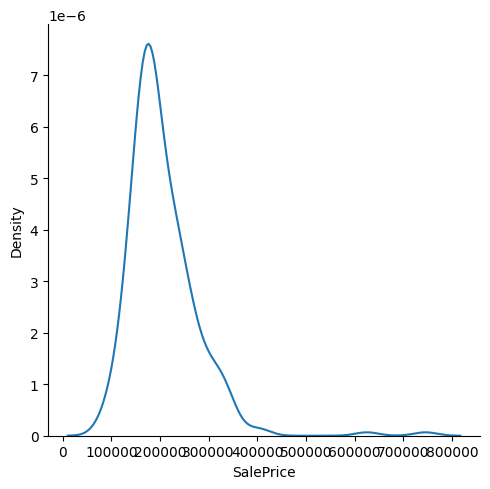

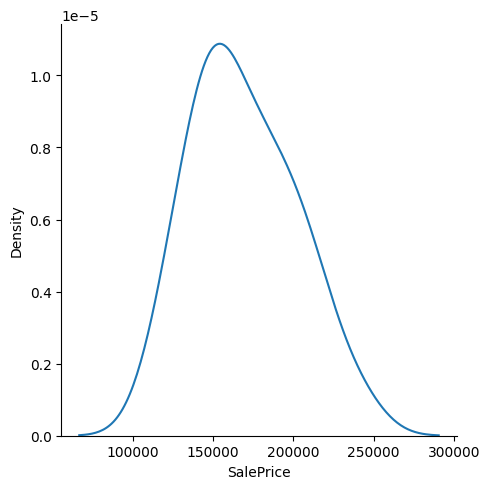

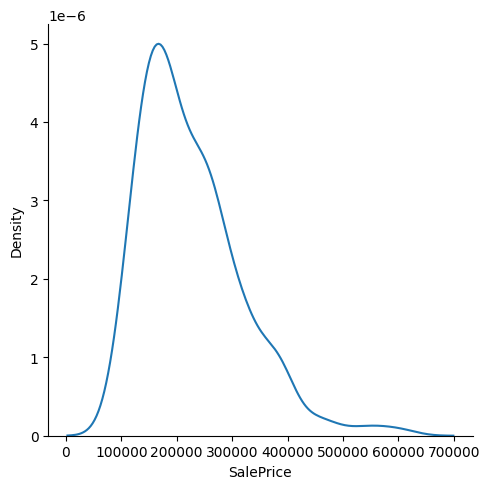

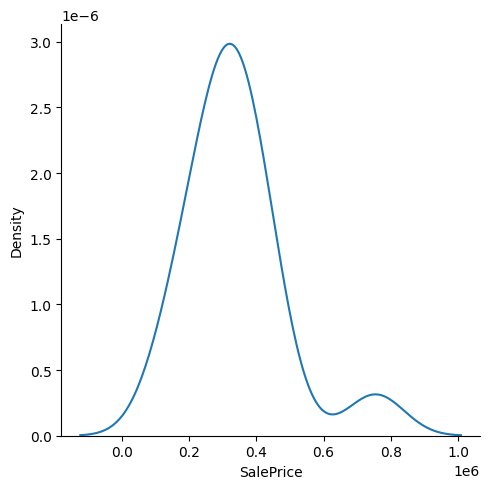

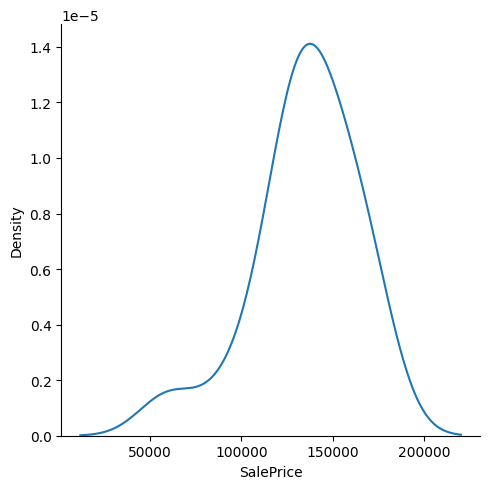

In [31]:
for category in x_train['FireplaceQu'].dropna().unique():
    sns.displot(x_train[x_train['FireplaceQu']== category]['SalePrice'],kind = 'kde',label = category)
    plt.show()

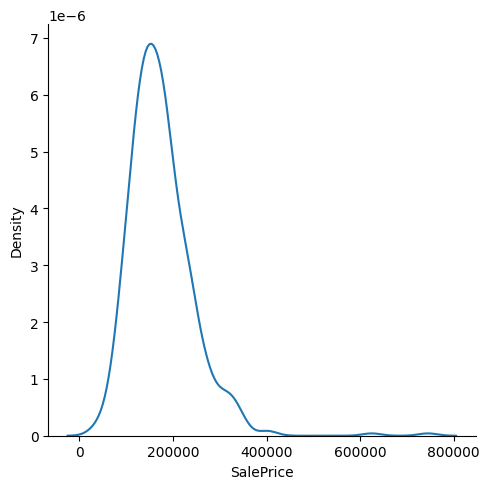

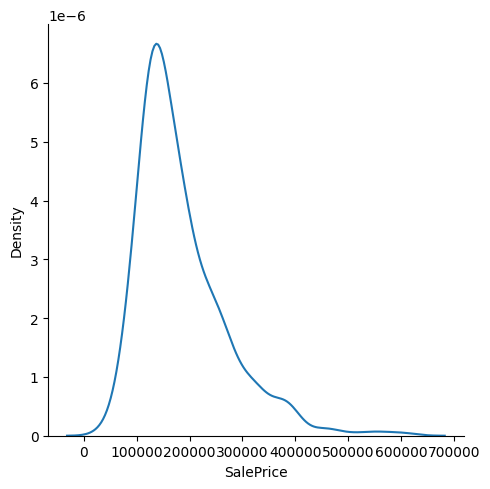

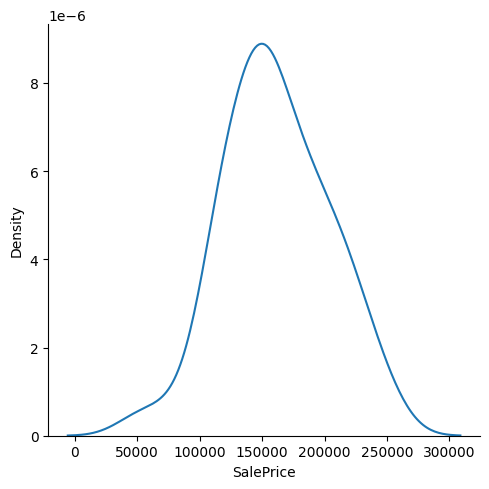

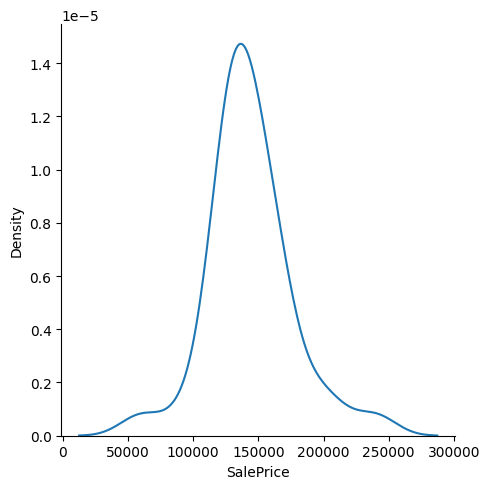

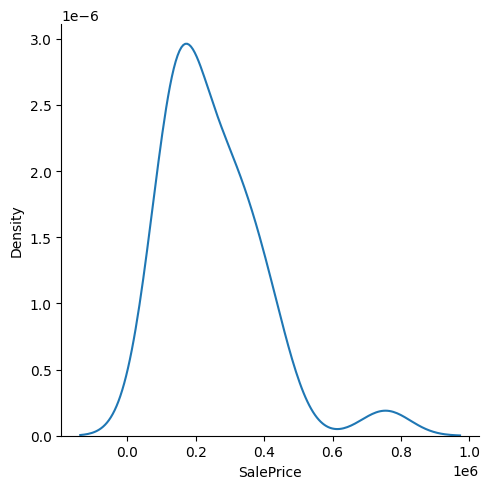

In [32]:
for category in x_train['FireplaceQu_imputed'].dropna().unique():
    sns.displot(x_train[x_train['FireplaceQu_imputed']== category]['SalePrice'],kind = 'kde',label = category)
    plt.show()

**Missing Indicator**- Make new column for each missing value

In [33]:
 import pandas as pd
import numpy as np

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.impute import MissingIndicator, SimpleImputer

In [35]:
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv', usecols = ['Age','Fare','Survived'])

In [36]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [37]:
x = df.drop(columns = ['Survived'])
y = df['Survived']

In [38]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 2)

In [39]:
x_train.head()

,Age,Fare
30,40.0,27.7208
10,4.0,16.7000
873,47.0,9.0000
182,9.0,31.3875
876,20.0,9.8458


In [40]:
si = SimpleImputer()
x_train_trf = si.fit_transform(x_train)
x_test_trf = si.transform(x_test)

In [41]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(x_train_trf, y_train)
y_pred = clf.predict(x_test_trf)
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.6145251396648045

In [42]:
mi = MissingIndicator()
mi.fit(x_train)

MissingIndicator()

In [43]:
x_train_missing = mi.transform(x_train)

In [44]:
x_test_missing = mi.transform(x_test)

In [45]:
x_train['Age_NA'] = x_train_missing
x_test['Age_NA'] = x_test_missing

In [46]:
x_train

,Age,Fare,Age_NA
30,40.0,27.7208,False
10,4.0,16.7000,False
873,47.0,9.0000,False
182,9.0,31.3875,False
876,20.0,9.8458,False
...,...,...,...
534,30.0,8.6625,False
584,NaN,8.7125,True
493,71.0,49.5042,False
527,NaN,221.7792,True


In [47]:
si = SimpleImputer()
x_train_trf2 = si.fit_transform(x_train)
x_test_trf2 = si.transform(x_test)

In [48]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(x_train_trf, y_train)
y_pred = clf.predict(x_test_trf)
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.6145251396648045

In [49]:
si = SimpleImputer(add_indicator = True)

In [50]:
x_train = si.fit_transform(x_train)

In [51]:
x_test = si.transform(x_test)

In [52]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(x_train_trf, y_train)
y_pred = clf.predict(x_test_trf)
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.6145251396648045

**Automatically select value for imputation**

In [53]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

In [54]:
df = pd.read_csv('/kaggle/input/competitions/titanic/train.csv')

In [55]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [56]:
df.drop(columns = ['PassengerId','Name','Ticket','Cabin'], inplace = True)

In [57]:
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S
3,1,1,female,35.0,1,0,53.1000,S
4,0,3,male,35.0,0,0,8.0500,S


In [58]:
x = df.drop(columns = ['Survived'])
y = df['Survived']

In [59]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 2)

In [60]:
x_train.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
30,1,male,40.0,0,0,27.7208,C
10,3,female,4.0,1,1,16.7000,S
873,3,male,47.0,0,0,9.0000,S
182,3,male,9.0,4,2,31.3875,S
876,3,male,20.0,0,0,9.8458,S


In [61]:
numerical_features = ['Age','Fare']
numerical_transformer = Pipeline(steps = [
    ('imputer',SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
    ])
categorical_features = ['Embarked','Sex']
categorical_transformer = Pipeline(steps = [
    ('imputer',SimpleImputer(strategy = 'most_frequent')),
    ('Ohe',OneHotEncoder(handle_unknown = 'ignore'))
])
preprocessor = ColumnTransformer(
    transformers = [
        ('nums',numerical_transformer,numerical_features)
    ]
)

In [62]:
clf = Pipeline(steps = [
    ('preprocessor',preprocessor),
    ('classifier',LogisticRegression())
])

In [63]:
from sklearn import set_config
set_config(display = 'diagram')
clf

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('nums',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Age', 'Fare'])])),
                ('classifier', LogisticRegression())])

In [64]:
param_grid = {
    'preprocessor_num_imputer_strategy':['mean','median'],
    'preprocessor_cat_imputer_strategy':['most_frequent','constant'],
}
grid_search = GridSearchCV(clf, param_grid, cv = 10)